In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
mse20 = pd.read_excel('../results.xlsx', sheet_name='original_MSE20', index_col='MSE20')
mae20 = pd.read_excel('../results.xlsx', sheet_name='original_MAE20', index_col='MAE20')
mse100 = pd.read_excel('../results.xlsx', sheet_name='original_MSE100', index_col='MSE100')
mae100 = pd.read_excel('../results.xlsx', sheet_name='original_MAE100', index_col='MAE100')

In [24]:
def bar_plot(df):
    plt.rcParams.update({'font.size': 5})
    fig, axs = plt.subplots(2, 2)
    for i, dataset in enumerate(df.columns):
        if 'MAE' in df.index.name:
            axs[np.floor(i/2).astype(int), i%2].bar(df.index, df[dataset], color='green')
        else:
            axs[np.floor(i/2).astype(int), i%2].bar(df.index, df[dataset])
        axs[np.floor(i/2).astype(int), i%2].set_title(f'{dataset}_{df.index.name}')
    plt.subplots_adjust(hspace=0.4, wspace=0.4)
    plt.tight_layout()
    plt.savefig(f'../plots/{df.index.name}.png', dpi=300)
    plt.show()

MSE100
FNN             6.642e-06
LSTM            5.643e-06
Transformer     5.352e-06
iTransformer    5.575e-06
dtype: object


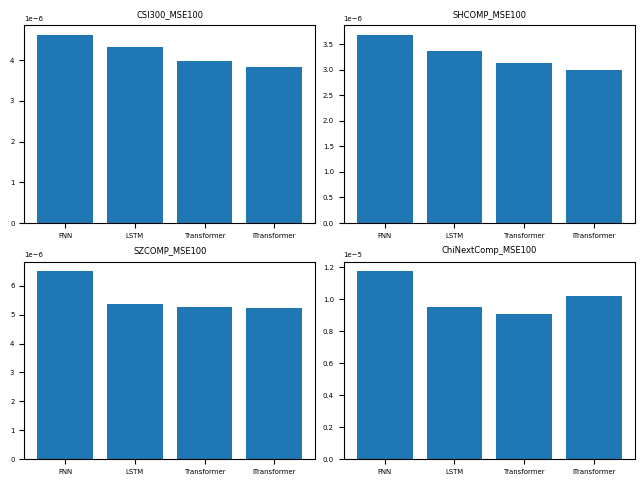

MAE100
FNN             1.652e-03
LSTM            1.380e-03
Transformer     1.196e-03
iTransformer    1.166e-03
dtype: object


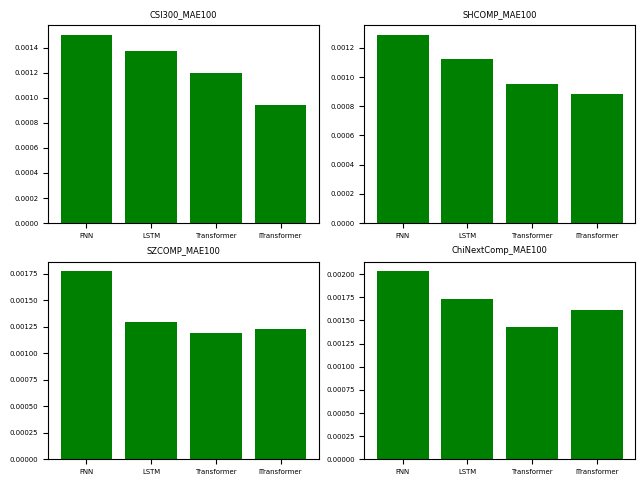

In [26]:
for df in (mse100, mae100):
    mean_values = df.mean(axis=1)

    # Convert to string with specified precision
    formatted_means = mean_values.apply(lambda x: f"{x:.3e}")

    # Display the formatted means
    print(formatted_means)
    bar_plot(df)

plotting the processed data

In [45]:
def plot_rv():
    plt.rcParams.update({'font.size': 5})
    fig, axs = plt.subplots(2, 2)
    for i, data_name in enumerate(['CSI300', 'SHCOMP', 'SZCOMP', 'ChiNextComp']):
        
        processed = pd.read_csv(f'../data/processed/{data_name}_1d.csv', index_col='timestamp')
        processed = processed['rv']
        axs[np.floor(i/2).astype(int), i%2].set_xlim(0, 0.016)
        axs[np.floor(i/2).astype(int), i%2].hist(processed, bins=128)
        axs[np.floor(i/2).astype(int), i%2].set_title(f'RV_{data_name}')
    plt.tight_layout()
    plt.savefig('../plots/daily_rv.png', dpi=300)
    plt.show()

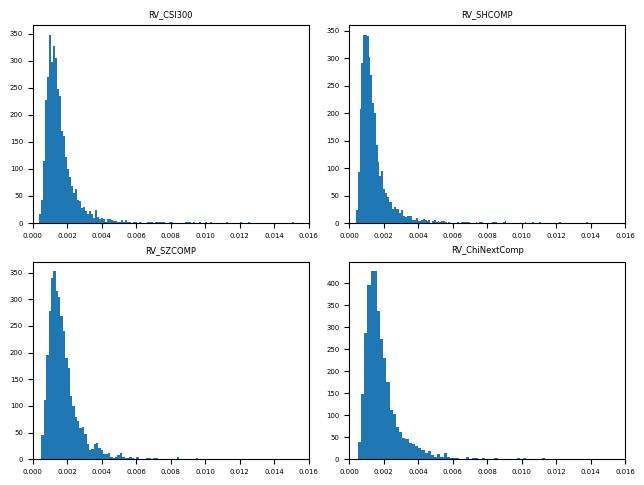

In [46]:
plot_rv()